# Academic PDF → Structured Markdown with Docling 2.x

This notebook builds a fast ingestion pipeline for born-digital academic PDFs (e.g., 2-column IEEE papers), extracting:
- Structured Markdown
- Tables
- Figures/Images
- Charts
- Formula enrichment

## Environment setup (uv)

Run these commands in a terminal from the project root:

```bash
uv add docling pillow ipykernel uuid6
uv run python -m ipykernel install --user --name docling --display-name "Python (docling)"
```

Then select the **Python (docling)** kernel for this notebook.

In [1]:
from pathlib import Path

input_pdf = Path("input\\Client Portfolio Analysis Report.pdf")

from docling.document_converter import DocumentConverter, PdfFormatOption
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import ThreadedPdfPipelineOptions, AcceleratorOptions
from docling_core.types.doc import PictureItem, TableItem


# Output path
output_dir = Path("output")
output_dir.mkdir(parents=True, exist_ok=True)

if not input_pdf.exists():
    raise FileNotFoundError(
        f"Input PDF not found at {input_pdf}. Place your PDF there or update input_pdf."
    )

c:\Users\Yoong Shen\Desktop\Docling_test\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
input_pdf = Path("input\\Client Portfolio Analysis Report.pdf")

In [14]:
# Lightweight markdown-first pipeline
pipeline_options = ThreadedPdfPipelineOptions()

# Stable low-memory inference target
pipeline_options.accelerator_options = AcceleratorOptions(
    device="cpu",
    num_threads=4,
    cuda_use_flash_attention2=False,
 )

CHUNK_SIZE = 6  # fixed chunk size for memory stability

# Core markdown quality options
pipeline_options.do_ocr = False  # born-digital PDFs
pipeline_options.do_table_structure = True

# Disable image-heavy enrichments
pipeline_options.generate_table_images = True
pipeline_options.generate_picture_images = True
pipeline_options.images_scale= 2.0
pipeline_options.generate_page_images = False
pipeline_options.do_chart_extraction = False
pipeline_options.do_formula_enrichment = False

# Conservative batching for low memory
pipeline_options.layout_batch_size = 4
pipeline_options.table_batch_size = 2

converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
    }
)

print(f"Docling converter initialized (MARKDOWN_ONLY), chunk_size={CHUNK_SIZE}.")
print(f"Accelerator device: {pipeline_options.accelerator_options.device}")

Docling converter initialized (MARKDOWN_ONLY), chunk_size=6.
Accelerator device: cpu


Converting pages 1-6 ...
self_ref='#/tables/0' parent=RefItem(cref='#/body') children=[] content_layer=<ContentLayer.BODY: 'body'> meta=None label=<DocItemLabel.TABLE: 'table'> prov=[ProvenanceItem(page_no=1, bbox=BoundingBox(l=73.92127227783203, t=467.09954833984375, r=513.5076904296875, b=264.2119140625, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 0))] source=[] comments=[] captions=[] references=[] footnotes=[] image=ImageRef(mimetype='image/png', dpi=144, size=Size(width=879.0, height=406.0), uri=AnyUrl('')) data=TableData(table_cells=[], num_rows=0, num_cols=0, grid=[]) annotations=[]
Converting pages 7-12 ...
Converted chunk passes: 1

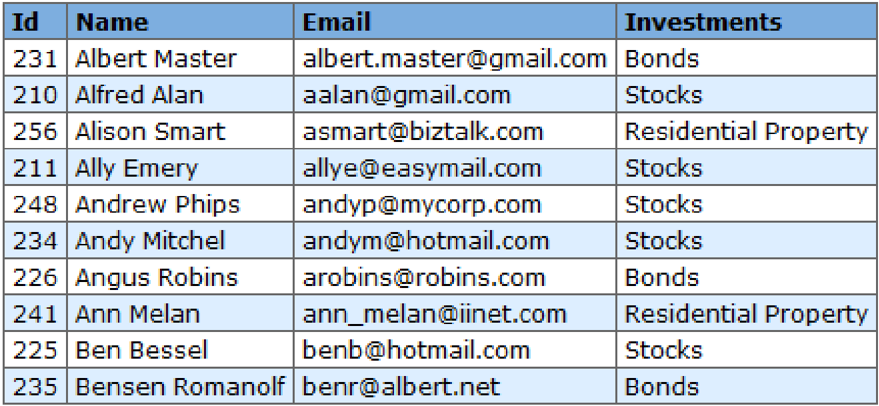

In [ ]:
from docling.datamodel.base_models import ConversionStatus
from docling_core.transforms.serializer.markdown import MarkdownDocSerializer
from uuid6 import uuid6

def convert_chunk(start_page: int, end_page: int):
    return converter.convert(
        str(input_pdf),
        raises_on_error=False,
        page_range=(start_page, end_page),
    )

markdown_chunks = []
chunk_failures = []
converted_chunks = 0
current_start = 1
table_counter = 1

while True:
    current_end = current_start + CHUNK_SIZE - 1
    print(f"Converting pages {current_start}-{current_end} ...")
    result = convert_chunk(current_start, current_end)

    if result.status in {ConversionStatus.FAILURE, ConversionStatus.SKIPPED}:
        break

    doc_filename = input_pdf.stem
    picture_counter = 1
    chunk_markdown_parts = []
    serializer = MarkdownDocSerializer(doc=result.document)

    for element, _ in result.document.iterate_items():
        if isinstance(element, PictureItem):
            print(element)
            element_image_filename = (
                output_dir / f"{doc_filename}-picture-{picture_counter}.png"
            )
            with element_image_filename.open("wb") as fp:
                element.get_image(result.document).save(fp, "PNG")
            picture_counter += 1

        if isinstance(element, TableItem):
            element_data = element.data
            if element_data.num_rows == 0 or element_data.num_cols == 0:
                table_image_name = (
                    f"{doc_filename}-table-{table_counter}-{uuid6()}.png"
                )
                element_image_filename = output_dir / table_image_name
                with element_image_filename.open("wb") as fp:
                    element.get_image(result.document).save(fp, "PNG")

                chunk_markdown_parts.extend(
                    [
                        "> **Table (image)**: Structure extraction failed (rows/cols = 0).",
                        f"> ![{table_image_name}]({table_image_name})",
                        "",
                    ]
                )
                table_counter += 1
                continue
            table_counter += 1

        serialized_text = serializer.serialize(item=element).text.strip()
        if serialized_text:
            chunk_markdown_parts.append(serialized_text)

    converted_chunks += 1
    chunk_markdown = "\n\n".join(chunk_markdown_parts).strip()
    if chunk_markdown:
        markdown_chunks.append(chunk_markdown)

    if result.status == ConversionStatus.PARTIAL_SUCCESS and result.errors:
        chunk_failures.append(
            {
                "range": f"{current_start}-{current_end}",
                "errors": [str(err) for err in result.errors],
            }
        )

    current_start += CHUNK_SIZE

if not markdown_chunks:
    raise RuntimeError(
        "No pages converted successfully. Try CHUNK_SIZE=4 for very constrained environments."
    )

markdown_text = "\n\n".join(markdown_chunks)
print(f"Converted chunk passes: {converted_chunks}")
if chunk_failures:
    print(f"Warning: {len(chunk_failures)} chunk(s) had partial errors.")

In [9]:
result

ConversionResult(version=DoclingVersion(docling_version='2.74.0', docling_core_version='2.65.2', docling_ibm_models_version='3.11.0', docling_parse_version='5.3.4', platform_str='Windows-10-10.0.26200-SP0', py_impl_version='cpython-311', py_lang_version='3.11.14'), timestamp=None, status=<ConversionStatus.FAILURE: 'failure'>, errors=[], pages=[], timings={}, confidence=ConfidenceReport(parse_score=nan, layout_score=nan, table_score=nan, ocr_score=nan, pages=defaultdict(<class 'docling.datamodel.base_models.PageConfidenceScores'>, {}), mean_grade=<QualityGrade.UNSPECIFIED: 'unspecified'>, low_grade=<QualityGrade.UNSPECIFIED: 'unspecified'>, mean_score=nan, low_score=nan), document=DoclingDocument(schema_name='DoclingDocument', version='1.9.0', name='dummy', origin=None, furniture=GroupItem(self_ref='#/furniture', parent=None, children=[], content_layer=<ContentLayer.FURNITURE: 'furniture'>, meta=None, name='_root_', label=<GroupLabel.UNSPECIFIED: 'unspecified'>), body=GroupItem(self_ref

In [17]:
# Persist combined Markdown generated from chunked conversion
markdown_path = output_dir / "document.md"
markdown_path.write_text(markdown_text, encoding="utf-8")

print(f"Markdown exported to: {markdown_path}")
print(f"Total converted chunks: {converted_chunks}")
print(f"Total partial-failure chunks: {len(chunk_failures)}")

Markdown exported to: output\document.md
Total converted chunks: 1
Total partial-failure chunks: 0
